In [27]:
import numpy as np
from astropy.io import fits
from astropy.table import Table 
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm 

In [28]:
sim = Table.read('MR7_z0.0_L150_h0.7.fits')
sim2 = Table.read('TNG_Mhalo_Mstar_h0.7.fits')
print(sim)

Mhalo = np.log10(sim['MVIR'])

tab = Table.read('SMF_Baldry2012.txt', format = 'ascii.commented_header')
Mstar = tab['Mass']
Ndens = tab['Density']


TYPE    X         Y        Z            MVIR        INFALLVMAX
---- -------- --------- -------- ------------------ ----------
   0  3.27417  74.68261 17.32758 1152069428571.4287  180.52757
   0  6.09376  80.91196  8.90322 1312528142857.1428  201.70636
   1  9.03828  74.13564  9.15919  53503015714.28572   71.65102
   0  0.94124  70.29736 12.89919 104246828571.42859    87.6633
   1  0.51411  70.06458 12.61891  65848628571.42857   70.21757
   0  13.0589  70.49874 16.80711 1736297714285.7144  199.12184
   2  1.84956  68.39413 11.03614  45289394285.71429   73.36893
   2  5.17399  61.57821  4.86685 233375357142.85718  122.67902
   1  15.8968  70.28729 18.53228  64485917142.85715   72.10719
   2 16.05532  70.29155 18.93444  538076285714.2857  154.58522
 ...      ...       ...      ...                ...        ...
   0 70.49201  87.81304  0.30187 119334428571.42857   80.43822
   0 67.10048  86.93721  0.03711 105618571428.57143   75.02401
   0 78.75689  86.47679  0.54733 131678828571.42859    

# TASK 1

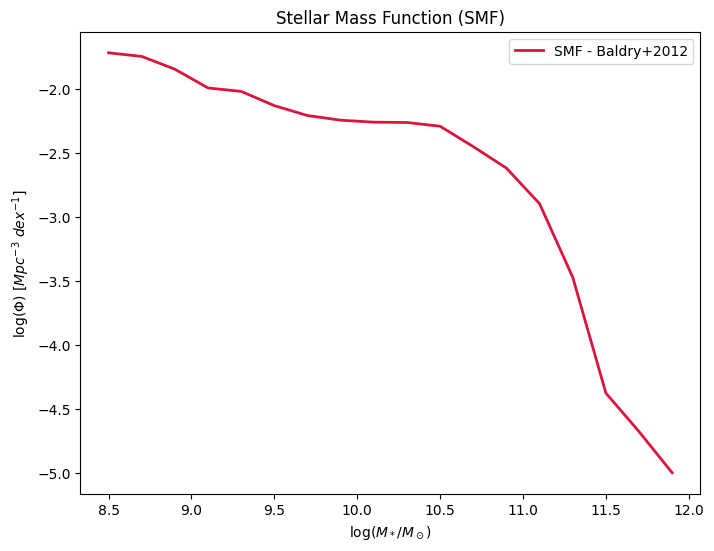

In [29]:
#plot the Stellar Mass Function 

plt.figure(figsize=(8,6))
plt.plot(Mstar, np.log10(Ndens), label='SMF - Baldry+2012', color = 'crimson',linewidth=2)

plt.xlabel(r'$\log(M_* / M_\odot)$')
plt.ylabel(r'$\log(\Phi) \ [Mpc^{-3} \ dex^{-1}]$')
plt.title('Stellar Mass Function (SMF)')
plt.legend()
plt.show()

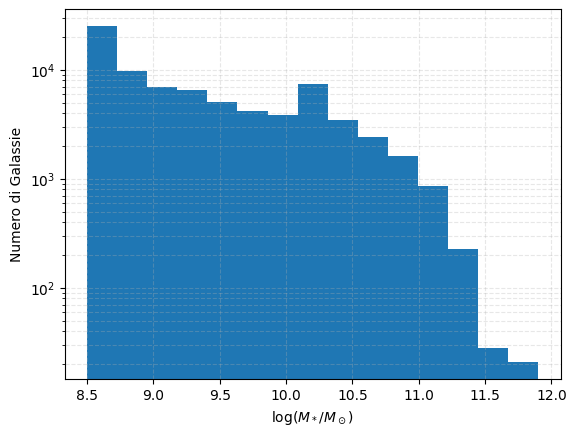

In [30]:
#plot the histogram

V = 150*150*150
bin_width = 0.2
Ngal = V * bin_width * Ndens
bins=np.arange(8.5,12, bin_width)


plt.hist(Mstar, bins=15, weights = Ngal)
plt.yscale('log')
plt.xlabel(r'$\log(M_* / M_\odot)$')
plt.ylabel('Numero di Galassie')
plt.grid(True, which="both", ls="--", alpha=0.3)

plt.show()

In [31]:
#generate the array of stellar mass values
Ngal_int = np.round(Ngal).astype(int)
gals_sim = []

for i in range(len(Mstar)):
    count = Ngal_int[i] 
    
    if count > 0:
        masses = np.random.uniform(Mstar[i] - bin_width/2, Mstar[i] + bin_width/2, count)
        gals_sim.extend(masses)

# Trasformiamo in array e ordiniamo (dal più grande al più piccolo)
gals_sim = np.sort(np.array(gals_sim))[::-1]

print(f"Fatto. Ora hai una lista di {len(gals_sim)} galassie")

Fatto. Ora hai una lista di 77205 galassie


# TASK 2 

Abbiamo 86124 aloni e 77205 galassie.


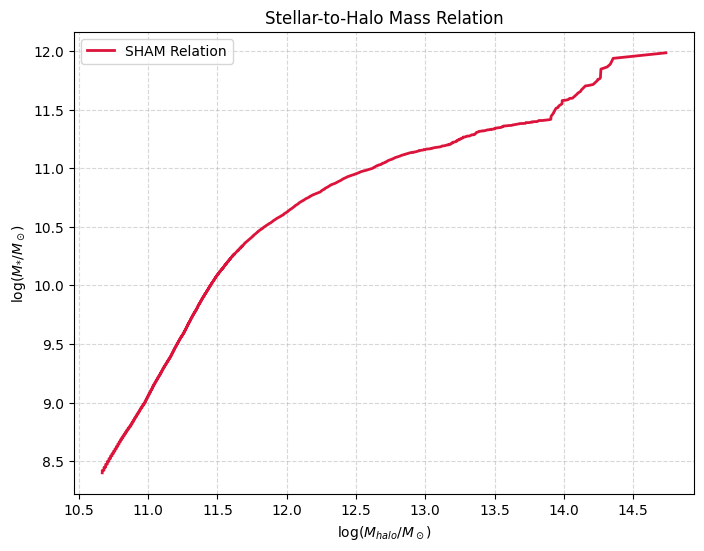

In [32]:

# sort the M_h and the M* arrays in decreasing order

Mhalo_sorted = np.sort(Mhalo)[::-1]
gals_sorted = np.sort(gals_sim)[::-1]

n_halos = len(Mhalo_sorted)
n_gals = len(gals_sorted)

print(f"Abbiamo {n_halos} aloni e {n_gals} galassie.") 

n_limit = min(n_halos, n_gals)

# Tagliamo le liste per averle della stessa lunghezza
Mhalo_matched = Mhalo_sorted[:n_limit]
gals_matched = gals_sorted[:n_limit]

plt.figure(figsize=(8,6))

plt.plot(Mhalo_matched, gals_matched, color='crimson', linewidth=2, label='SHAM Relation')
plt.xlabel(r'$\log(M_{halo} / M_\odot)$')
plt.ylabel(r'$\log(M_{*} / M_\odot)$')
plt.title('Stellar-to-Halo Mass Relation')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.savefig("SHMR.png", dpi=300, bbox_inches="tight")
plt.show()



# TASK 3

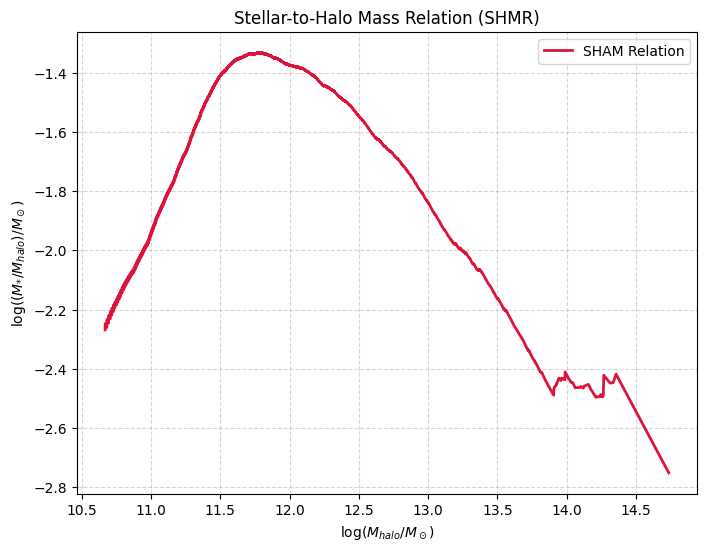

In [33]:
plt.figure(figsize=(8,6))

plt.plot(Mhalo_matched, gals_matched-Mhalo_matched, color='crimson', linewidth=2, label='SHAM Relation')

plt.xlabel(r'$\log(M_{halo} / M_\odot)$')
plt.ylabel(r'$\log((M_{*}/M_{halo}) / M_\odot)$')
plt.title('Stellar-to-Halo Mass Relation (SHMR)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()


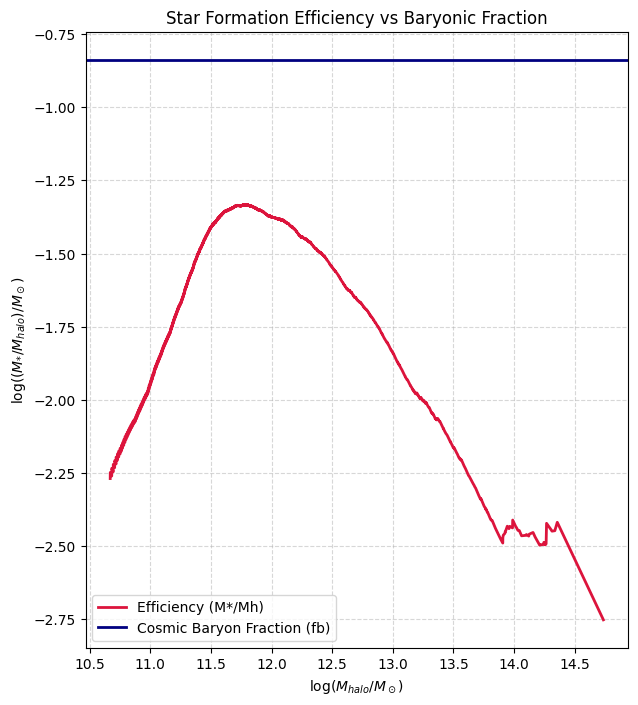

In [34]:
plt.figure(figsize=(7,8))

Omegab = 0.045
OmegaM = 0.31
baryonic_fraction = Omegab/OmegaM

plt.plot(Mhalo_matched, gals_matched-Mhalo_matched, color='crimson', linewidth=2, label='Efficiency (M*/Mh)')
plt.axhline(y=np.log10(baryonic_fraction), color='navy', linestyle='-', linewidth=2, label='Cosmic Baryon Fraction (fb)')
plt.xlabel(r'$\log(M_{halo} / M_\odot)$')
plt.ylabel(r'$\log((M_{*}/M_{halo}) / M_\odot)$')
plt.title('Star Formation Efficiency vs Baryonic Fraction')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("efficiency.png", dpi=300, bbox_inches="tight")


# TASK 4 

In [35]:
print(sim2)


  Mhalo      Mstar  
---------- ---------
 14.511355 12.543224
 13.646507 11.721618
 12.999758 11.771732
 12.635597 11.208762
 12.630438 11.099329
 12.595133 11.258008
 12.411658 11.435824
 12.239434 11.259246
 12.157809 11.322946
 12.205867 11.277814
       ...       ...
 11.008166  8.955741
 11.000268  9.193335
 11.020902  9.208287
 11.006754 8.7885685
 11.027032  8.776821
 11.007926  9.077652
 11.002279  8.625223
 11.038674   8.89078
 11.011184  9.111081
11.0118685  8.691083
Length = 16899 rows


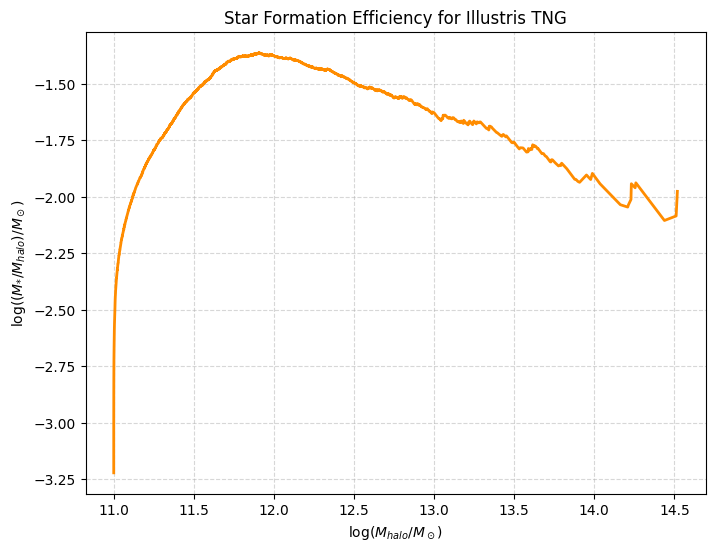

In [40]:
tab2 = Table.read('TNG_Mhalo_Mstar_h0.7.fits')
Mhalo_TNG = tab2['Mhalo']
Mstar_TNG = tab2['Mstar']

Mhalo_TNG_sorted = np.sort(Mhalo_TNG)[::-1]
Mstar_TNG_sorted = np.sort(Mstar_TNG)[::-1]

plt.figure(figsize=(8,6))

plt.plot(Mhalo_TNG_sorted, Mstar_TNG_sorted - Mhalo_TNG_sorted, color='darkorange', linewidth=2, )

plt.xlabel(r'$\log(M_{halo} / M_\odot)$')
plt.ylabel(r'$\log((M_{*}/M_{halo}) / M_\odot)$')
plt.title('Star Formation Efficiency for Illustris TNG')
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("illustris.png", dpi=300, bbox_inches="tight")
plt.show()

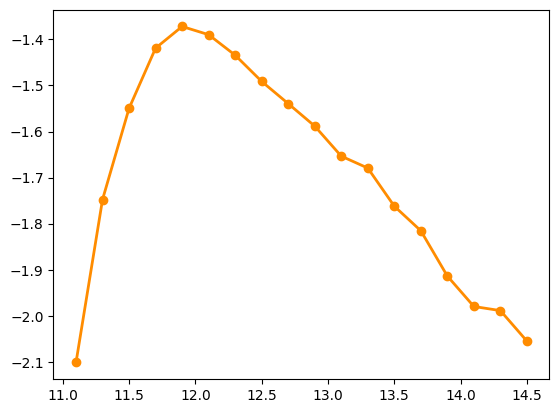

In [42]:
bins_edges = np.arange(10, 15, 0.2)
bin_centers = []
mean_efficiency = []

efficiency_TNG = Mstar_TNG_sorted - Mhalo_TNG_sorted

for i in range(len(bins_edges)-1):
    mask = (Mhalo_TNG_sorted >= bins_edges[i]) & (Mhalo_TNG_sorted < bins_edges[i+1])
    
    if np.sum(mask) > 0:
        # Calcoliamo la media dell'efficienza in questo bin
        avg = np.mean(efficiency_TNG[mask])
        mean_efficiency.append(avg)
        bin_centers.append((bins_edges[i] + bins_edges[i+1])/2.0)

plt.plot(bin_centers, mean_efficiency, color='darkorange', marker='o', linewidth=2, label='Illustris TNG')


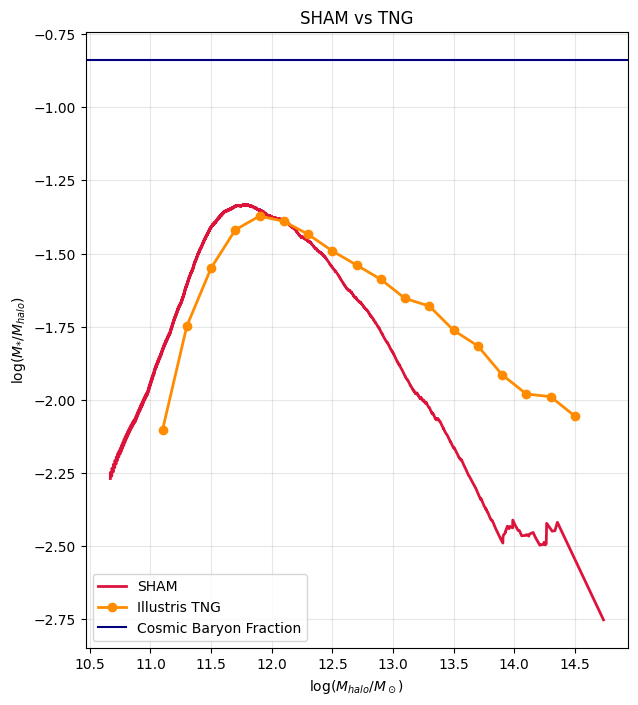

In [46]:
plt.figure(figsize=(7,8))
plt.plot(Mhalo_matched, gals_matched - Mhalo_matched, color='crimson', linewidth=2, linestyle='-', label='SHAM')

plt.plot(bin_centers, mean_efficiency, color='darkorange', marker='o', linewidth=2, label='Illustris TNG')

plt.axhline(y=np.log10(baryonic_fraction), color='navy', linestyle='-', label='Cosmic Baryon Fraction')

plt.xlabel(r'$\log(M_{halo} / M_\odot)$')
plt.ylabel(r'$\log(M_{*} / M_{halo})$')
plt.title('SHAM vs TNG')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("confrontofinale.png", dpi=300, bbox_inches="tight")

plt.show()